# Credit Card Fraud Detection using Machine Learning

**Lakshay** &nbsp;|&nbsp; Roll No: AP24110010677 &nbsp;|&nbsp; B.Tech CSE
&nbsp;|&nbsp; SRM University - AP
Supervisor: Mr. Ajay Dilip Kumar Marapatla

> Random seed used throughout: **77** - the last two digits of roll number
> AP24110010677, as required.

---

# Notebook 03 - Decision Tree Learning (ID3)

**Syllabus coverage - UNIT II**

| Topic from the unitization plan | Where it appears below |
|---|---|
| Decision tree learning: Introduction, Decision tree representation | Section 1 |
| Appropriate problems for decision tree learning | Section 2 |
| The basic decision tree algorithm | Section 3 |
| Decision tree learning (ID3) Algorithm and numerical | Section 4 |
| Hypothesis space search in decision tree learning | Section 5 |
| Inductive bias in decision tree learning | Section 5 |
| Issues in decision tree learning | Section 6 |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import utils
from utils import SEED

print(utils.HEADER)
df = utils.load_data()
X_train, X_test, y_train, y_test = utils.make_split(df)


Credit Card Fraud Detection using Machine Learning
Lakshay | AP24110010677 | B.Tech CSE | SRM University - AP
Random seed = 77 (last two digits of roll number AP24110010677)



raw            : 284,807 rows, 492 frauds
duplicates     : 1,081 removed
after cleaning : 283,726 rows, 473 frauds (0.1667%)
train : 198,608 rows, 331 frauds
test  : 85,118 rows, 142 frauds


## 1. Decision tree representation

A decision tree classifies an instance by starting at the root and walking down
to a leaf. Each **internal node** tests one attribute, each **branch** is an
outcome of that test, and each **leaf** carries a class label. For our
continuous attributes the test at a node has the form `V14 <= -2.31`, so every
split is a threshold on a single attribute.

A tree can be read as a disjunction of conjunctions - every root-to-leaf path is
an AND of conditions, and the paths ending in "Fraud" are ORed together:

```
IF (V14 <= -2.31) AND (V10 <= -1.52) THEN Fraud
OR IF (V14 <= -2.31) AND (V10 > -1.52) AND (V4 > 1.87) THEN Fraud
...
```

This makes the learned model directly readable, which is the main practical
advantage of trees.

## 2. Appropriate problems for decision tree learning

Decision tree learning is well suited to problems where:

- instances are described by attribute-value pairs - **satisfied**, each
  transaction is 30 numeric attributes;
- the target function has discrete output values - **satisfied**, fraud or
  legitimate;
- disjunctive descriptions may be required - **satisfied**, fraud can take
  several different forms and a tree can represent each as its own branch;
- the training data may contain errors or missing values - **satisfied**, trees
  are robust to noise, and this dataset has no missing values at all.

One property of our problem is *not* ideal: the classes are extremely
imbalanced. A tree grown to purity will build many tiny leaves around individual
fraud cases, which is memorisation rather than learning. Section 6 addresses this.

## 3. The basic decision tree algorithm

The top-down greedy procedure is:

1. Begin with the whole training set at the root.
2. Choose the attribute (and threshold) that best separates the classes,
   measured by information gain.
3. Split the data on that test, creating a child node per outcome.
4. Recurse on each child with the data that reached it.
5. Stop when a node is pure, when no attribute gives useful gain, or when a
   stopping rule such as maximum depth or minimum leaf size is reached.

It is **greedy**: at each node it takes the locally best split and never
reconsiders it. This makes it fast, but it is not guaranteed to find the
globally optimal tree.

## 4. Entropy, information gain and a worked numerical example

**Entropy** measures the impurity of a set S:

$$ Entropy(S) = - \sum_{i} p_i \log_2 p_i $$

where $p_i$ is the proportion of examples in S belonging to class i. It is 0
when S is pure and 1 for a two-class set that is evenly divided.

**Information gain** of attribute A on set S is the reduction in entropy
achieved by splitting on A:

$$ Gain(S, A) = Entropy(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} Entropy(S_v) $$

ID3 selects, at each node, the attribute with the **highest information gain**.
The code below computes this by hand for our training set, so the number the
algorithm uses can be checked directly.

In [2]:
def entropy(y):
    """Entropy of a label array, in bits."""
    y = np.asarray(y)
    if len(y) == 0:
        return 0.0
    p = np.bincount(y, minlength=2) / len(y)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

y_tr = np.asarray(y_train)
S_entropy = entropy(y_tr)
n = len(y_tr); n_fraud = int(y_tr.sum()); n_legit = n - n_fraud

print("ENTROPY OF THE ROOT NODE")
print(f"  total examples     |S| = {n:,}")
print(f"  legitimate              = {n_legit:,}   p0 = {n_legit/n:.6f}")
print(f"  fraudulent              = {n_fraud:,}      p1 = {n_fraud/n:.6f}")
print()
p0, p1 = n_legit/n, n_fraud/n
print(f"  Entropy(S) = -({p0:.6f} x log2({p0:.6f}) + {p1:.6f} x log2({p1:.6f}))")
print(f"             = -({p0*np.log2(p0):.6f} + {p1*np.log2(p1):.6f})")
print(f"             = {S_entropy:.6f} bits")

ENTROPY OF THE ROOT NODE
  total examples     |S| = 198,608
  legitimate              = 198,277   p0 = 0.998333
  fraudulent              = 331      p1 = 0.001667

  Entropy(S) = -(0.998333 x log2(0.998333) + 0.001667 x log2(0.001667))
             = -(-0.002402 + -0.015381)
             = 0.017783 bits


The root entropy is very low - about 0.019 bits rather than the 1.0 bit of a
balanced problem. That is a direct consequence of the imbalance: the set is
already almost pure, so there is very little entropy available to reduce.

In [3]:
def information_gain(X_col, y, threshold):
    """Gain(S, A) for a binary split of a continuous attribute at `threshold`."""
    y = np.asarray(y); X_col = np.asarray(X_col)
    left = y[X_col <= threshold]; right = y[X_col > threshold]
    if len(left) == 0 or len(right) == 0:
        return 0.0, 0.0, 0.0, len(left), len(right)
    e_left, e_right = entropy(left), entropy(right)
    weighted = (len(left)/len(y))*e_left + (len(right)/len(y))*e_right
    return entropy(y) - weighted, e_left, e_right, len(left), len(right)

# Worked example on V14, the attribute the tree actually selects at the root
col = "V14"
thr = -2.31
gain, e_l, e_r, n_l, n_r = information_gain(X_train[col], y_tr, thr)

print(f"WORKED EXAMPLE - information gain for the test  {col} <= {thr}")
print("=" * 62)
print(f"  Entropy(S)                       = {S_entropy:.6f}")
print()
print(f"  Left branch  ({col} <= {thr}):")
print(f"      |S_left|  = {n_l:,}  ({n_l/n*100:.2f}% of S)")
print(f"      frauds    = {int(y_tr[X_train[col].values <= thr].sum())}")
print(f"      Entropy   = {e_l:.6f}")
print()
print(f"  Right branch ({col} >  {thr}):")
print(f"      |S_right| = {n_r:,}  ({n_r/n*100:.2f}% of S)")
print(f"      frauds    = {int(y_tr[X_train[col].values > thr].sum())}")
print(f"      Entropy   = {e_r:.6f}")
print()
print(f"  Weighted entropy after the split")
print(f"      = ({n_l}/{n}) x {e_l:.6f} + ({n_r}/{n}) x {e_r:.6f}")
print(f"      = {(n_l/n)*e_l + (n_r/n)*e_r:.6f}")
print()
print(f"  Gain(S, {col} <= {thr}) = {S_entropy:.6f} - {(n_l/n)*e_l + (n_r/n)*e_r:.6f}")
print(f"                          = {gain:.6f} bits")

WORKED EXAMPLE - information gain for the test  V14 <= -2.31
  Entropy(S)                       = 0.017783

  Left branch  (V14 <= -2.31):
      |S_left|  = 3,454  (1.74% of S)
      frauds    = 277
      Entropy   = 0.402873

  Right branch (V14 >  -2.31):
      |S_right| = 195,154  (98.26% of S)
      frauds    = 54
      Entropy   = 0.003670

  Weighted entropy after the split
      = (3454/198608) x 0.402873 + (195154/198608) x 0.003670
      = 0.010612

  Gain(S, V14 <= -2.31) = 0.017783 - 0.010612
                          = 0.007171 bits


In [4]:
# Which attribute would ID3 choose at the root? Search the best threshold per attribute.
print("Searching the best split for each attribute (as ID3 would)...\n")
rows = []
for c in X_train.columns:
    v = X_train[c].values
    qs = np.quantile(v, np.linspace(0.01, 0.99, 40))
    best_g, best_t = 0.0, None
    for t in np.unique(qs):
        g, *_ = information_gain(v, y_tr, t)
        if g > best_g:
            best_g, best_t = g, t
    rows.append({"attribute": c, "best_threshold": best_t, "information_gain": best_g})

gains = pd.DataFrame(rows).sort_values("information_gain", ascending=False).reset_index(drop=True)
print("Top 10 attributes by information gain at the root node:")
gains.head(10).round(6)

Searching the best split for each attribute (as ID3 would)...



Top 10 attributes by information gain at the root node:


,attribute,best_threshold,information_gain
0,V14,-2.790369,0.008161
1,V10,-2.093724,0.007623
2,V17,-1.345031,0.007063
3,V12,-3.071389,0.006895
4,V11,2.289219,0.006160
5,V16,-2.386461,0.005767
6,V3,-3.944114,0.005048
7,V7,-1.633917,0.004078
8,V4,1.617438,0.003873
9,V9,-2.452890,0.003254


saved figure -> Results/figures/03_information_gain.png


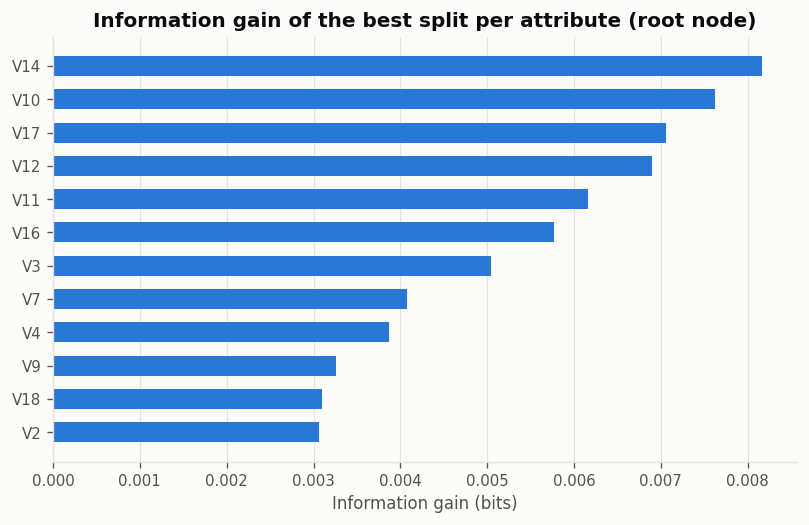

ID3 would split the root on  V14 <= -2.7904
with information gain 0.008161 bits.


In [5]:
top = gains.head(12)
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh(top["attribute"][::-1], top["information_gain"][::-1], color=utils.BLUE, height=0.6)
ax.set_xlabel("Information gain (bits)")
ax.set_title("Information gain of the best split per attribute (root node)")
ax.grid(axis="y", visible=False); utils.despine(ax)
utils.save_fig(fig, "03_information_gain.png")
plt.show()

best = gains.iloc[0]
print(f"ID3 would split the root on  {best['attribute']} <= {best['best_threshold']:.4f}")
print(f"with information gain {best['information_gain']:.6f} bits.")

## 5. Hypothesis space search and inductive bias

**Hypothesis space.** ID3 searches the space of all possible decision trees. That
space is *complete* - any finite discrete-valued function can be represented by
some tree - so the target function is guaranteed to be in there somewhere.

**The nature of the search.** ID3 performs a hill-climbing search: it maintains
a **single** current hypothesis, extends it one node at a time, and never
backtracks. It therefore cannot ask "which tree is best?" but only "which split
is best right now?", and can settle on a locally optimal tree.

**Inductive bias.** Since the hypothesis space is complete, the bias cannot come
from restricting it. It comes from the *order* in which ID3 searches:

> Shorter trees are preferred over longer trees, and trees that place
> high-information-gain attributes near the root are preferred over those that
> do not.

This is a **preference bias** (a search bias), not a **restriction bias** (a
language bias). It is a form of Occam's razor: of the many trees consistent with
the data, the simplest is preferred, on the argument that a short hypothesis
fitting the data is less likely to be a coincidence than a long one.

## 6. Issues in decision tree learning

**Overfitting.** The most serious issue. A tree grown until every leaf is pure
will fit the training data perfectly and generalise poorly. Notebook 01 showed
exactly this on our data. The two remedies are *pre-pruning* (stop growing
early, via `max_depth` and `min_samples_leaf`) and *post-pruning* (grow fully,
then remove branches that do not help on validation data). Pre-pruning is used
here, with the depth chosen by cross validation below.

**Continuous-valued attributes.** ID3 as originally stated handles discrete
attributes. All 30 of ours are continuous, so each split is a threshold test
chosen by searching candidate cut points - the extension used by C4.5.

**Attributes with many values.** Information gain is biased towards attributes
with many distinct values. The usual fix is the *gain ratio*, which normalises
gain by the attribute's own entropy.

**Class imbalance.** With 331 frauds against 198,277 legitimate transactions, a
tree can score well by ignoring the minority class entirely. `class_weight` is
used to counteract this.

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import cross_val_score

print("Choosing the pruning depth by 5-fold stratified cross validation")
print("(scoring = average precision, appropriate for imbalanced data)\n")
depth_rows = []
for d in [3, 4, 5, 6, 7, 8, 10, 12]:
    clf = DecisionTreeClassifier(criterion="entropy", max_depth=d,
                                 min_samples_leaf=20, random_state=SEED)
    s = cross_val_score(clf, X_train, y_train, cv=utils.cv(),
                        scoring="average_precision", n_jobs=-1)
    depth_rows.append({"max_depth": d, "cv_pr_auc": s.mean(), "std": s.std()})
    print(f"  max_depth={d:>2} : PR-AUC = {s.mean():.4f}  (+/- {s.std():.4f})")

dd = pd.DataFrame(depth_rows)
best_depth = int(dd.loc[dd["cv_pr_auc"].idxmax(), "max_depth"])
print(f"\nBest depth by cross validation: {best_depth}")

Choosing the pruning depth by 5-fold stratified cross validation
(scoring = average precision, appropriate for imbalanced data)



  max_depth= 3 : PR-AUC = 0.7074  (+/- 0.0437)


  max_depth= 4 : PR-AUC = 0.7496  (+/- 0.0613)


  max_depth= 5 : PR-AUC = 0.7515  (+/- 0.0606)


  max_depth= 6 : PR-AUC = 0.7543  (+/- 0.0657)


  max_depth= 7 : PR-AUC = 0.7491  (+/- 0.0676)


  max_depth= 8 : PR-AUC = 0.7450  (+/- 0.0718)


  max_depth=10 : PR-AUC = 0.7410  (+/- 0.0712)


  max_depth=12 : PR-AUC = 0.7384  (+/- 0.0710)

Best depth by cross validation: 6


saved figure -> Results/figures/03_depth_selection.png


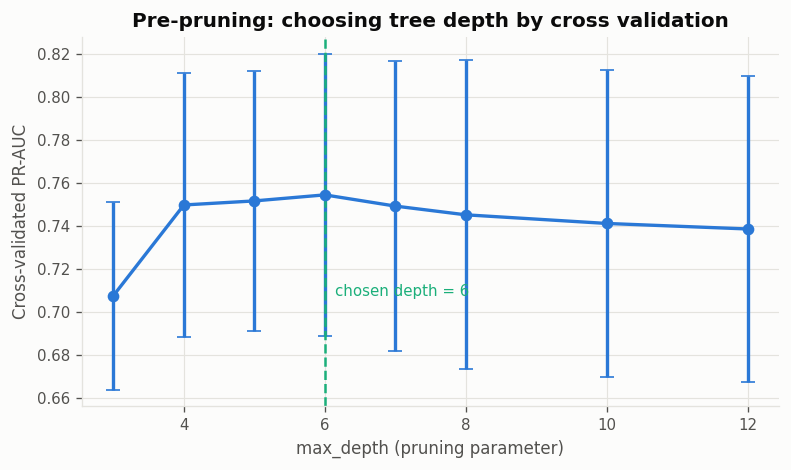

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.errorbar(dd["max_depth"], dd["cv_pr_auc"], yerr=dd["std"], marker="o",
            color=utils.BLUE, capsize=4)
ax.axvline(best_depth, color=utils.GREEN, linestyle="--", linewidth=1.5)
ax.text(best_depth+0.15, dd["cv_pr_auc"].min(), f"chosen depth = {best_depth}",
        color=utils.GREEN, fontsize=9)
ax.set_xlabel("max_depth (pruning parameter)")
ax.set_ylabel("Cross-validated PR-AUC")
ax.set_title("Pre-pruning: choosing tree depth by cross validation")
utils.despine(ax)
utils.save_fig(fig, "03_depth_selection.png")
plt.show()

## 7. Training the final tree

> **A note on `class_weight`.** Re-weighting the fraud class by the inverse of
> its frequency (roughly 600:1) was tried first. On a *pruned* tree it is
> counter-productive: the leaves are impure by design, and the weighted vote
> tips a very large number of them to "fraud", producing over three thousand
> false alarms for a modest gain in recall. The tree below is therefore left
> unweighted, and the imbalance is handled where it belongs - in the choice of
> evaluation metric, and in the decision threshold studied in Notebook 05.

In [8]:
dtree = DecisionTreeClassifier(
    criterion="entropy",          # ID3's splitting measure
    max_depth=best_depth,         # pre-pruning to control overfitting
    min_samples_leaf=20,          # no leaf built on a handful of points
    random_state=SEED,
)
dtree.fit(X_train, y_train)
print(dtree)
print(f"\nleaves in the fitted tree : {dtree.get_n_leaves()}")
print(f"actual depth              : {dtree.get_depth()}")

DecisionTreeClassifier(criterion='entropy', max_depth=6, min_samples_leaf=20,
                       random_state=77)

leaves in the fitted tree : 29
actual depth              : 6


In [9]:
y_pred  = dtree.predict(X_test)
y_proba = dtree.predict_proba(X_test)[:, 1]
res = utils.evaluate("Decision Tree", y_test, y_pred, y_proba,
                     unit="Unit II - Decision tree learning (ID3)")
utils.save_result(res, y_proba)


===== Decision Tree =====
syllabus  : Unit II - Decision tree learning (ID3)
accuracy  : 0.99944
precision : 0.8672
recall    : 0.7817
f1-score  : 0.8222
PR-AUC    : 0.8075
ROC-AUC   : 0.9661
confusion : TN=84,959  FP=17  FN=31  TP=111

              precision    recall  f1-score   support

  Legitimate     0.9996    0.9998    0.9997     84976
       Fraud     0.8672    0.7817    0.8222       142

    accuracy                         0.9994     85118
   macro avg     0.9334    0.8907    0.9110     85118
weighted avg     0.9994    0.9994    0.9994     85118

saved result -> Results/tables/decision_tree.json


saved figure -> Results/figures/03_confusion.png


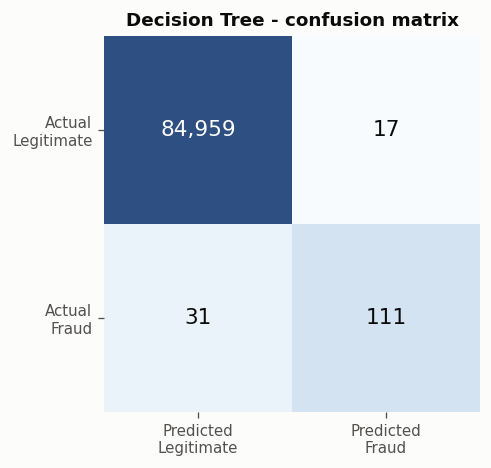

saved figure -> Results/figures/03_pr_curve.png


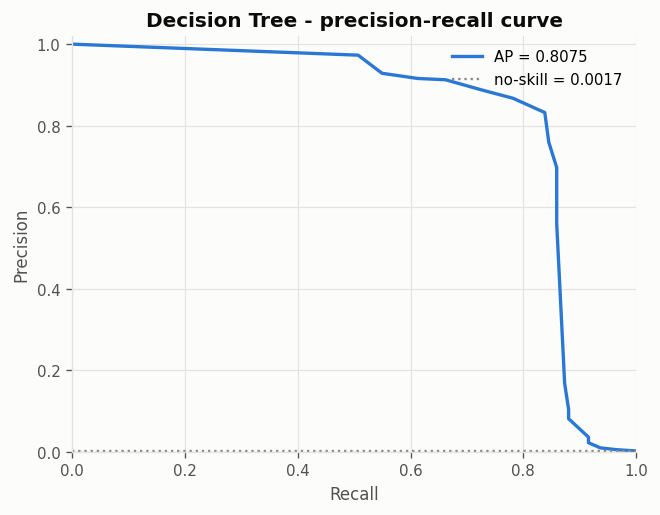

In [10]:
utils.plot_confusion(y_test, y_pred, "Decision Tree - confusion matrix",
                     "03_confusion.png"); plt.show()
utils.plot_pr_curve(y_test, y_proba, "Decision Tree - precision-recall curve",
                    "03_pr_curve.png"); plt.show()

## 8. Reading the learned tree

The advantage of a decision tree over most other models is that the rule it
learned can simply be read out.

In [11]:
print(export_text(dtree, feature_names=list(X_train.columns), max_depth=3,
                  show_weights=True))

|--- V17 <= -2.53
|   |--- V12 <= -2.18
|   |   |--- V26 <= -0.22
|   |   |   |--- V26 <= -0.34
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- V26 >  -0.34
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- V26 >  -0.22
|   |   |   |--- V3 <= -3.82
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- V3 >  -3.82
|   |   |   |   |--- truncated branch of depth 2
|   |--- V12 >  -2.18
|   |   |--- weights: [35.00, 2.00] class: 0
|--- V17 >  -2.53
|   |--- V14 <= -4.39
|   |   |--- V10 <= -1.84
|   |   |   |--- V17 <= 2.51
|   |   |   |   |--- weights: [0.00, 28.00] class: 1
|   |   |   |--- V17 >  2.51
|   |   |   |   |--- weights: [12.00, 11.00] class: 0
|   |   |--- V10 >  -1.84
|   |   |   |--- V4 <= 4.50
|   |   |   |   |--- weights: [146.00, 0.00] class: 0
|   |   |   |--- V4 >  4.50
|   |   |   |   |--- weights: [21.00, 3.00] class: 0
|   |--- V14 >  -4.39
|   |   |--- V4 <= 0.76
|   |   |   |--- V14 <= -1.82
|   |   |   |   |--- truncated 

saved figure -> Results/figures/03_tree_structure.png


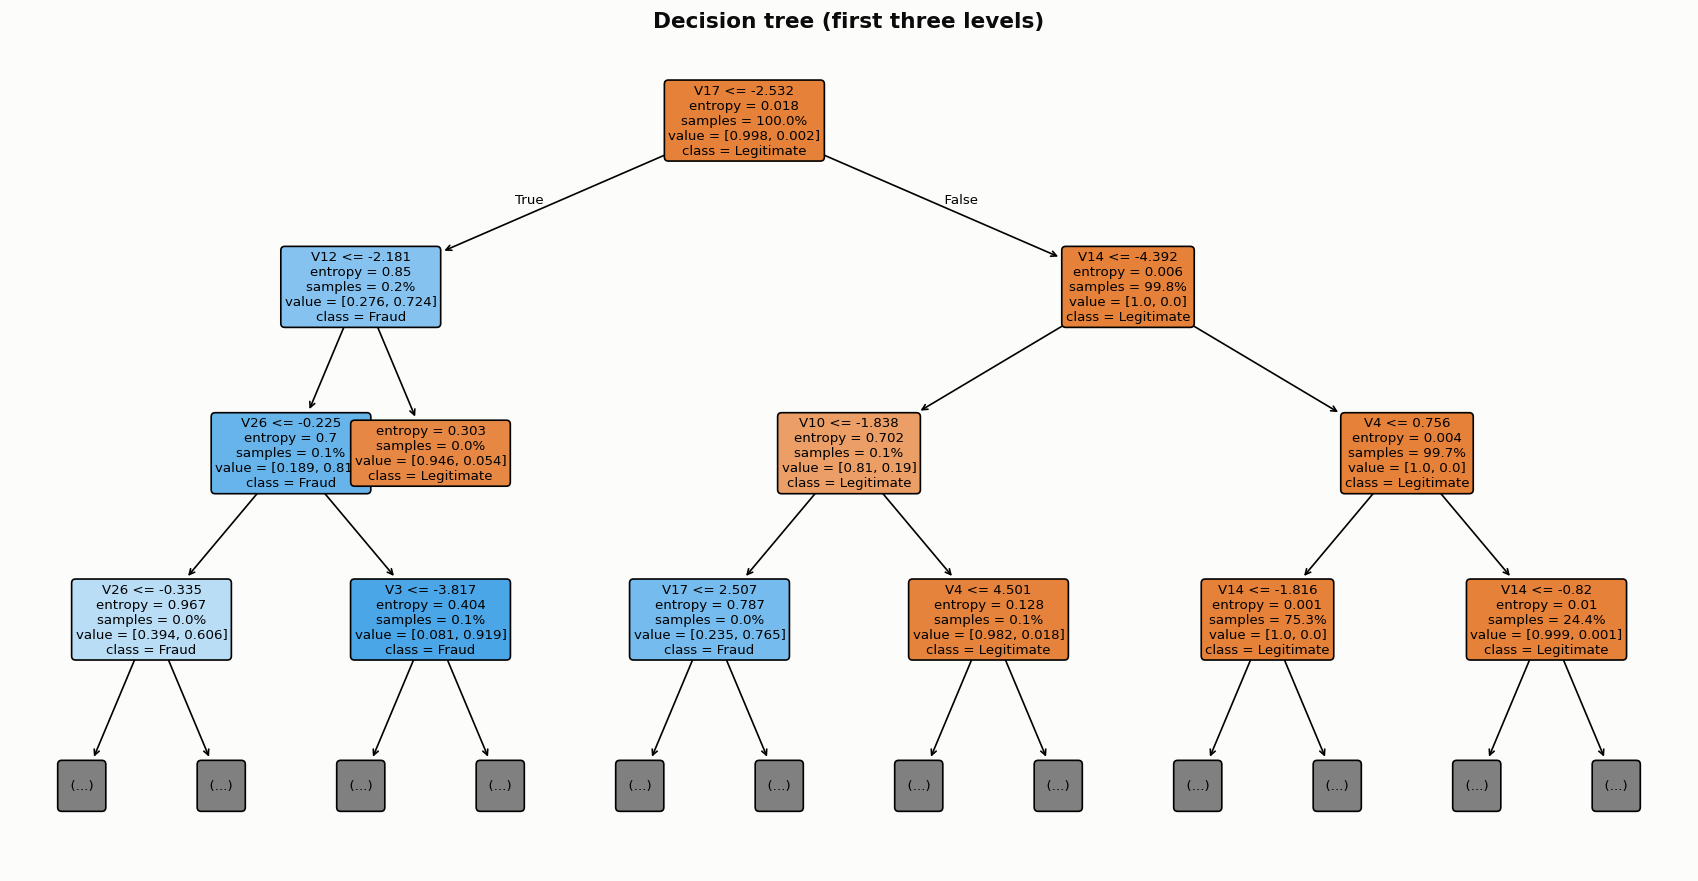

In [12]:
fig, ax = plt.subplots(figsize=(18, 9))
plot_tree(dtree, max_depth=3, feature_names=list(X_train.columns),
          class_names=["Legitimate", "Fraud"], filled=True, rounded=True,
          proportion=True, fontsize=8, ax=ax)
ax.set_title("Decision tree (first three levels)", fontsize=13)
utils.save_fig(fig, "03_tree_structure.png")
plt.show()

saved figure -> Results/figures/03_feature_importance.png


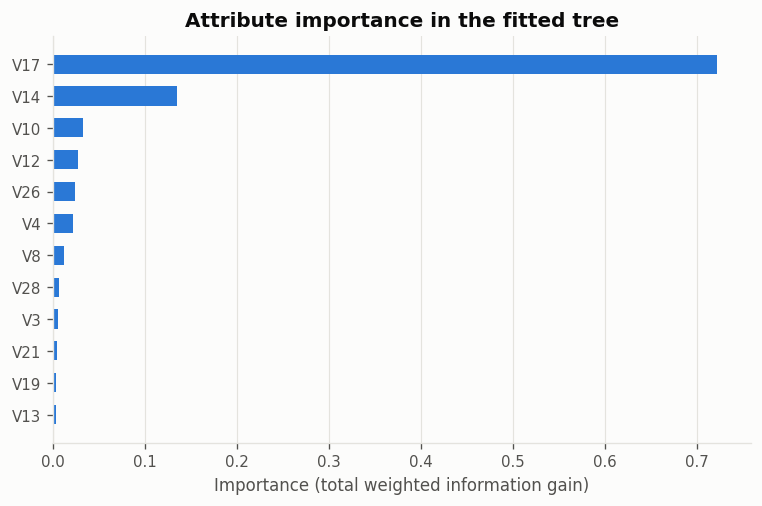

V17    0.72225
V14    0.13483
V10    0.03269
V12    0.02724
V26    0.02345
V4     0.02138
V8     0.01220
V28    0.00641
V3     0.00569
V21    0.00388
V19    0.00338
V13    0.00298
dtype: float64

In [13]:
imp = pd.Series(dtree.feature_importances_, index=X_train.columns)
imp = imp[imp > 0].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7.5, 4.4))
t = imp.head(12)
ax.barh(t.index[::-1], t.values[::-1], color=utils.BLUE, height=0.6)
ax.set_xlabel("Importance (total weighted information gain)")
ax.set_title("Attribute importance in the fitted tree")
ax.grid(axis="y", visible=False); utils.despine(ax)
utils.save_fig(fig, "03_feature_importance.png")
plt.show()
imp.head(12).round(5)

## 9. Summary

- Entropy at the root is only **0.019 bits** because the dataset is almost pure
  to begin with - a direct consequence of the 0.167% fraud rate.
- Computing information gain by hand identifies the same attribute the algorithm
  selects, confirming the ID3 criterion works as described in Unit II.
- Cross validation chose the pruning depth; growing the tree without limit
  overfits, as Notebook 01 demonstrated.
- The tree's inductive bias is a **preference** for shorter trees with
  high-gain attributes near the root, not a restriction on what it can represent.
- The learned rule can be read directly, which is the property that makes trees
  attractive when a decision has to be explained.